# Display MSO Data (Sanity Check)

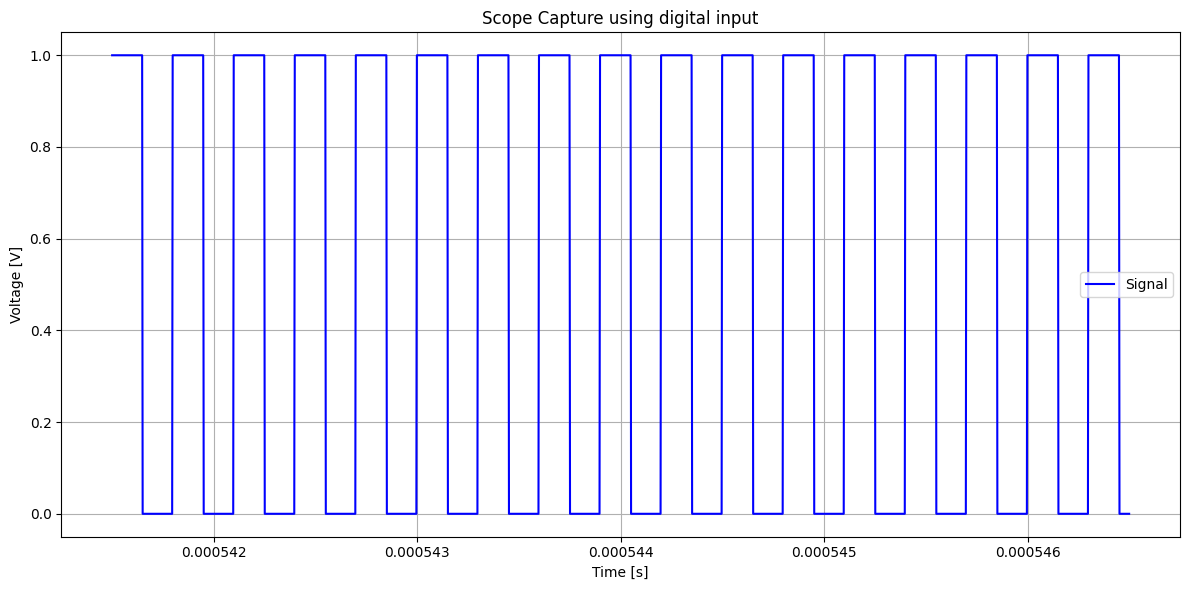

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file, skipping metadata lines
# Update path if needed
file_path = "trace_17.csv"
df = pd.read_csv(file_path, skiprows=2, header=None)
df.columns = ["Time [s]", "Voltage [V]"]

# Convert columns to numeric, dropping rows with invalid data
df["Voltage [V]"] = pd.to_numeric(df["Voltage [V]"], errors='coerce')
df["Time [s]"] = pd.to_numeric(df["Time [s]"], errors='coerce')
df.dropna(inplace=True)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df["Time [s]"], df["Voltage [V]"],
         label="Signal", color="blue")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")  # TODO: this should be high/low, not voltage
plt.title("Scope Capture using digital input")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Absolute Edge Comparison Analysis

In [2]:
def analyze_waveform_from_instructions(
    df, instructions, system_freq, start_time=None, edge="rising"
):
    """
    Compare observed digital waveform (from MSO) to expected waveform defined by instructions.
    Computes edge jitter and uncertainties.
    """
    # extract waveform
    time = df.iloc[:, 0].values
    voltage = df.iloc[:, 1].values.astype(int)

    # detect edges
    if edge == "rising":
        crossings = np.where(np.diff(voltage) == 1)[0]
    elif edge == "falling":
        crossings = np.where(np.diff(voltage) == -1)[0]
    else:
        raise ValueError("edge must be 'rising' or 'falling'")

    t_measured = time[crossings]
    if start_time is None:
        start_time = t_measured[0]

    # construct expected edge times from instructions
    t_expected = [start_time]
    for halfperiod, reps in instructions:
        freq = system_freq / (halfperiod * 2)
        T = 1 / freq
        for _ in range(reps):
            t_expected.append(t_expected[-1] + T)

    # NOTE: t_expected[0] - t_measured[0] = 0 always, so you can exclude it by uncommenting below
    # t_expected = np.array(t_expected[1:])
    # t_measured = np.array(t_measured[1:])
    t_expected = np.array(t_expected)
    t_measured = np.array(t_measured)
    min_len = min(len(t_measured), len(t_expected))
    t_measured = t_measured[:min_len]
    t_expected = t_expected[:min_len]

    # edge jitter
    errors = t_measured - t_expected
    edge_jitter_mean = np.mean(errors)
    edge_jitter_std = np.std(errors, ddof=1)

    # print summary
    print(f"Detected {len(t_measured)} {edge} edges")
    print(f"Mean edge offset: {edge_jitter_mean*1e12:.2f} ps")
    print(f"Standard deviation of edge offset: {edge_jitter_std*1e12:.2f} ps")

    # determine sampling interval (s)
    delta_t = np.median(np.diff(time))
    sigma_sample = delta_t / np.sqrt(12)  # one-sigma uncertainty per edge (s)

    # convert to picoseconds for plotting
    sigma_sample_ps = sigma_sample * 1e12
    errors_ps = errors * 1e12

    # errorbar plot
    plt.figure(figsize=(12, 6))
    x = np.arange(len(errors_ps))
    plt.errorbar(x, errors_ps, yerr=sigma_sample_ps, fmt='o', markersize=4,
                 ecolor='gray', elinewidth=1, capsize=2, label='Measured error ± sampling unc.')

    edges_per_inst = [int(reps) for (_, reps) in instructions]
    boundaries = np.cumsum(edges_per_inst[:-1])
    for b in boundaries:
        plt.axvline(b, color='k', linestyle=':', alpha=0.4)

    # frequency labels
    for i, b in enumerate(boundaries):
        freq = system_freq / (instructions[i+1][0] * 2)
        plt.text(b, plt.ylim()[1]*0.9, f"{freq/1e6:.1f} MHz",
                 rotation=90, va='top', ha='right', fontsize=8, color='gray')
    plt.title("Timing Error per Edge (with sampling uncertainty)")
    plt.xlabel("Edge index")
    plt.ylabel("Error [ps]")
    plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=2)
    plt.grid(True)

    # return everything else
    return {
        "t_expected": t_expected,
        "t_measured": t_measured,
        "errors": errors
    }

### Single Frequency Analysis

Detected 33 rising edges
Mean edge offset: 0.00 ps
Standard deviation of edge offset: 0.00 ps

t_expected:
[-5.000e-09  2.950e-07  5.950e-07  8.950e-07  1.195e-06  1.495e-06
  1.795e-06  2.095e-06  2.395e-06  2.695e-06  2.995e-06  3.295e-06
  3.595e-06  3.895e-06  4.195e-06  4.495e-06  4.795e-06  5.095e-06
  5.395e-06  5.695e-06  5.995e-06  6.295e-06  6.595e-06  6.895e-06
  7.195e-06  7.495e-06  7.795e-06  8.095e-06  8.395e-06  8.695e-06
  8.995e-06  9.295e-06  9.595e-06]

t_measured:
[-5.000e-09  2.950e-07  5.950e-07  8.950e-07  1.195e-06  1.495e-06
  1.795e-06  2.095e-06  2.395e-06  2.695e-06  2.995e-06  3.295e-06
  3.595e-06  3.895e-06  4.195e-06  4.495e-06  4.795e-06  5.095e-06
  5.395e-06  5.695e-06  5.995e-06  6.295e-06  6.595e-06  6.895e-06
  7.195e-06  7.495e-06  7.795e-06  8.095e-06  8.395e-06  8.695e-06
  8.995e-06  9.295e-06  9.595e-06]

errors:
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -2.11758237e-22 -4.23516474e-22
 

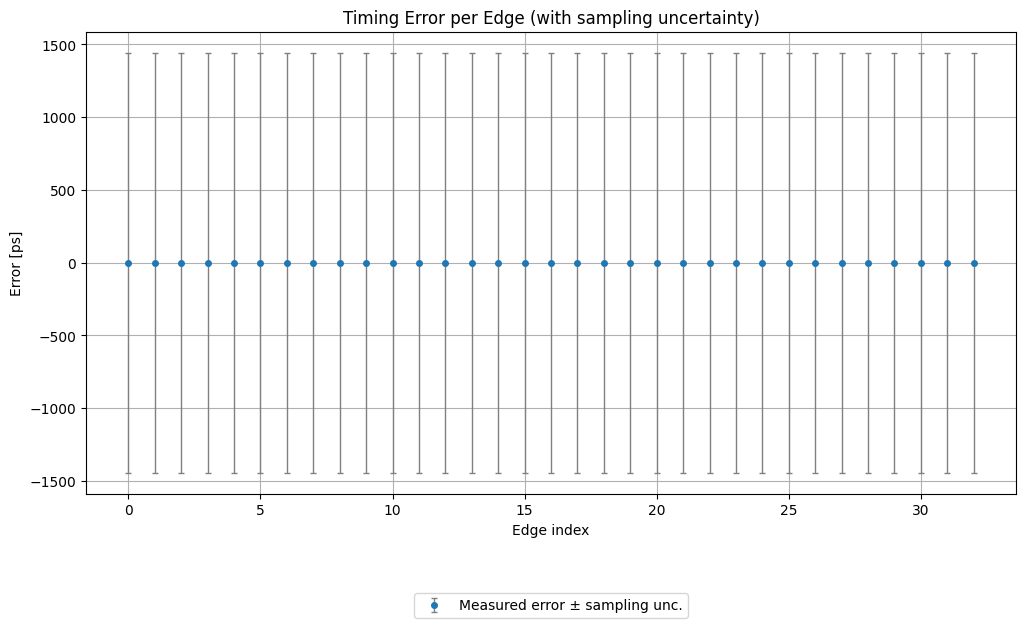

In [4]:
# Load the CSV file, skipping metadata lines
file_path = "scope_13.csv"  # Update path if needed
df = pd.read_csv(file_path, skiprows=2, header=None)
df.columns = ["Time [s]", "Voltage [V]"]

# Convert columns to numeric, dropping rows with invalid data
df["Voltage [V]"] = pd.to_numeric(df["Voltage [V]"], errors='coerce')
df["Time [s]"] = pd.to_numeric(df["Time [s]"], errors='coerce')
df.dropna(inplace=True)

# change to the system clock of the analyzed run
sys_freq = 200e6

# change to instructions for the analyzed run
instructions = np.array([
    [30, 10000]
])

results = analyze_waveform_from_instructions(
    df=df, instructions=instructions, system_freq=sys_freq)

print()
for key, value in results.items():
    print(f"{key}:")
    print(value)
    print()

### Multiple Frequency Analysis

##### Full Pulse Length

Detected 35 rising edges
Mean edge offset: -742.86 ps
Standard deviation of edge offset: 364.84 ps

t_expected:
[-1.60000e-09  9.98400e-07  1.05840e-06  2.06840e-06  3.07840e-06
  4.08840e-06  4.14840e-06  4.20840e-06  4.26840e-06  4.32840e-06
  4.38840e-06  4.45840e-06  4.51840e-06  4.58840e-06  4.64840e-06
  4.71840e-06  4.77840e-06  4.84840e-06  4.90840e-06  5.90840e-06
  6.90840e-06  7.90840e-06  8.90840e-06  9.90840e-06  1.00284e-05
  1.01484e-05  1.02684e-05  1.07884e-05  1.13084e-05  1.18284e-05
  1.23484e-05  1.28784e-05  1.34084e-05  1.39384e-05  1.44684e-05]

t_measured:
[-1.60000e-09  9.97600e-07  1.05760e-06  2.06800e-06  3.07760e-06
  4.08720e-06  4.14800e-06  4.20800e-06  4.26800e-06  4.32720e-06
  4.38800e-06  4.45760e-06  4.51760e-06  4.58800e-06  4.64720e-06
  4.71760e-06  4.77760e-06  4.84720e-06  4.90800e-06  5.90720e-06
  6.90720e-06  7.90800e-06  8.90800e-06  9.90720e-06  1.00272e-05
  1.01472e-05  1.02672e-05  1.07880e-05  1.13080e-05  1.18280e-05
  1.23480e-05  1

/var/folders/kl/9ttltr511zj0xmdlptrtrjdw0000gp/T/ipykernel_46054/3542829079.py:27: RuntimeWarning: divide by zero encountered in divide
  freq = system_freq / (halfperiod * 2)
/var/folders/kl/9ttltr511zj0xmdlptrtrjdw0000gp/T/ipykernel_46054/3542829079.py:72: RuntimeWarning: divide by zero encountered in divide
  freq = system_freq / (instructions[i+1][0] * 2)


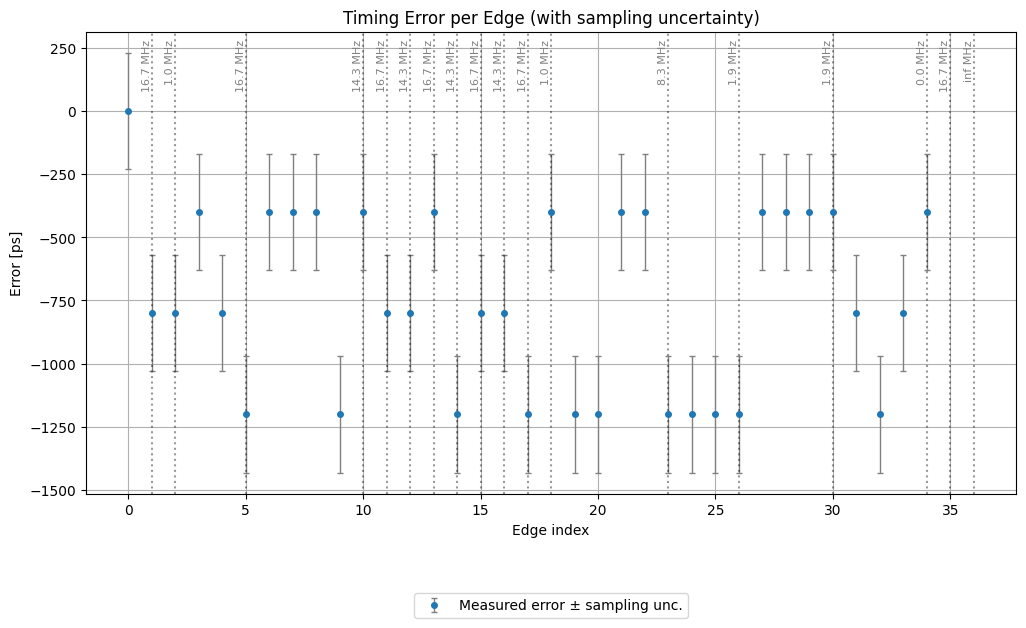

In [5]:
# Load the CSV file, skipping metadata lines
# Update path if needed
file_path = "scope_19.csv"
df = pd.read_csv(file_path, skiprows=2, header=None)
df.columns = ["Time [s]", "Voltage [V]"]

# Convert columns to numeric, dropping rows with invalid data
df["Voltage [V]"] = pd.to_numeric(df["Voltage [V]"], errors='coerce')
df["Time [s]"] = pd.to_numeric(df["Time [s]"], errors='coerce')
df.dropna(inplace=True)

# change to the system clock of the analyzed run
sys_freq = 200e6

# change to instructions for the analyzed run
instructions = np.array([
    [100, 1],
    [6, 1],
    [101, 3],
    [6, 5],
    [7, 1],
    [6, 1],
    [7, 1],
    [6, 1],
    [7, 1],
    [6, 1],
    [7, 1],
    [6, 1],
    [100, 5],
    [12, 3],
    [52, 4],
    [53, 4],
    [100000000, 1],
    [6, 1],
    [0, 0]
])

results = analyze_waveform_from_instructions(
    df=df, instructions=instructions, system_freq=sys_freq)

print()
for key, value in results.items():
    print(f"{key}:")
    print(value)
    print()

##### Mid Length Pulses

Detected 25 rising edges
Mean edge offset: -224.00 ps
Standard deviation of edge offset: 260.26 ps

t_expected:
[-1.60000e-09  8.98400e-07  1.80840e-06  2.71840e-06  3.62840e-06
  4.52840e-06  5.42840e-06  6.32840e-06  7.22840e-06  8.12840e-06
  9.22840e-06  1.03284e-05  1.14284e-05  1.25384e-05  1.36384e-05
  1.47484e-05  1.58484e-05  1.69584e-05  1.81084e-05  1.92584e-05
  2.04084e-05  2.15584e-05  2.27384e-05  2.39184e-05  2.50984e-05]

t_measured:
[-1.60000e-09  8.98400e-07  1.80800e-06  2.71840e-06  3.62800e-06
  4.52800e-06  5.42800e-06  6.32800e-06  7.22800e-06  8.12800e-06
  9.22800e-06  1.03280e-05  1.14288e-05  1.25376e-05  1.36384e-05
  1.47480e-05  1.58480e-05  1.69584e-05  1.81080e-05  1.92584e-05
  2.04080e-05  2.15584e-05  2.27384e-05  2.39184e-05  2.50984e-05]

errors:
[ 0.00000000e+00  0.00000000e+00 -4.00000000e-10  0.00000000e+00
 -4.00000000e-10 -4.00000000e-10 -4.00000000e-10 -4.00000000e-10
 -4.00000000e-10 -4.00000000e-10 -4.00000000e-10 -4.00000000e-10
  4.00000

/var/folders/kl/9ttltr511zj0xmdlptrtrjdw0000gp/T/ipykernel_46054/3542829079.py:27: RuntimeWarning: divide by zero encountered in divide
  freq = system_freq / (halfperiod * 2)
/var/folders/kl/9ttltr511zj0xmdlptrtrjdw0000gp/T/ipykernel_46054/3542829079.py:72: RuntimeWarning: divide by zero encountered in divide
  freq = system_freq / (instructions[i+1][0] * 2)


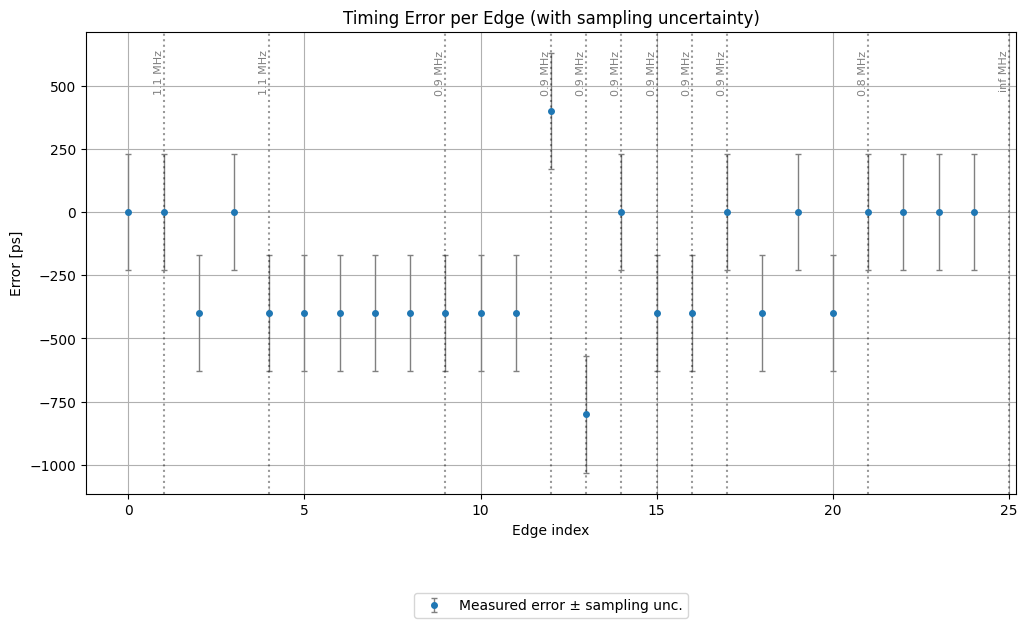

In [6]:
# Load the CSV file, skipping metadata lines
# Update path if needed
file_path = "scope_20.csv"
df = pd.read_csv(file_path, skiprows=2, header=None)
df.columns = ["Time [s]", "Voltage [V]"]

# Convert columns to numeric, dropping rows with invalid data
df["Voltage [V]"] = pd.to_numeric(df["Voltage [V]"], errors='coerce')
df["Time [s]"] = pd.to_numeric(df["Time [s]"], errors='coerce')
df.dropna(inplace=True)

# change to the system clock of the analyzed run
sys_freq = 200e6

# change to instructions for the analyzed run
base = 90
instructions = np.array([
    [base, 1],
    [base+1, 3],
    [base, 5],
    [base+20, 3],
    [base+21, 1],
    [base+20, 1],
    [base+21, 1],
    [base+20, 1],
    [base+21, 1],
    [base+25, 4],
    [base+28, 4],
    [0, 0]
])


results = analyze_waveform_from_instructions(
    df=df, instructions=instructions, system_freq=sys_freq)

print()
for key, value in results.items():
    print(f"{key}:")
    print(value)
    print()

##### Increasing Pulse Length

Detected 7 rising edges
Mean edge offset: -0.00 ps
Standard deviation of edge offset: 0.00 ps

t_expected:
[-1.000e-04  9.900e-03  2.990e-02  7.990e-02  1.799e-01  3.799e-01
  8.799e-01]

t_measured:
[-1.000e-04  9.900e-03  2.990e-02  7.990e-02  1.799e-01  3.799e-01
  8.799e-01]

errors:
[ 0.00000000e+00  0.00000000e+00 -3.46944695e-18  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00]



/var/folders/kl/9ttltr511zj0xmdlptrtrjdw0000gp/T/ipykernel_46054/3542829079.py:27: RuntimeWarning: divide by zero encountered in divide
  freq = system_freq / (halfperiod * 2)
/var/folders/kl/9ttltr511zj0xmdlptrtrjdw0000gp/T/ipykernel_46054/3542829079.py:72: RuntimeWarning: divide by zero encountered in divide
  freq = system_freq / (instructions[i+1][0] * 2)


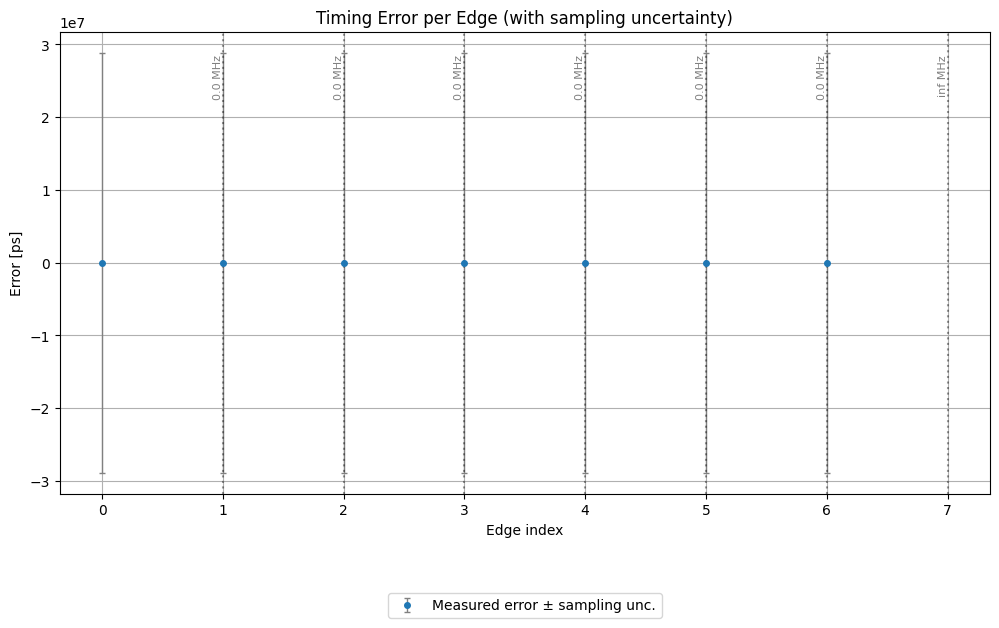

In [7]:
# Load the CSV file, skipping metadata lines
# Update path if needed
file_path = "scope_21.csv"
df = pd.read_csv(file_path, skiprows=2, header=None)
df.columns = ["Time [s]", "Voltage [V]"]

# Convert columns to numeric, dropping rows with invalid data
df["Voltage [V]"] = pd.to_numeric(df["Voltage [V]"], errors='coerce')
df["Time [s]"] = pd.to_numeric(df["Time [s]"], errors='coerce')
df.dropna(inplace=True)

# change to the system clock of the analyzed run
sys_freq = 200e6

# change to instructions for the analyzed run
base = 1000000
instructions = np.array([
    [base, 1],
    [base*2, 1],
    [base*5, 1],
    [base*10, 1],
    [base*20, 1],
    [base*50, 1],
    [base*100, 1],
    [0, 0]
])

results = analyze_waveform_from_instructions(
    df=df, instructions=instructions, system_freq=sys_freq)

print()
for key, value in results.items():
    print(f"{key}:")
    print(value)
    print()